In [1]:
import pandas as pd
import plotly.express as px

In [2]:
apc_table = pd.read_csv('./data/apc.csv', dtype={'bus': str, 'route': str, 'variant': str, 'block': str, 'direction': str, 'trip': str, 'stop_id': str, 'stop_seq_id': int})
stops_table = pd.read_csv('./data/stops.csv', dtype={'stop_id': str})
trips_table = pd.read_csv('./data/trips.csv', dtype={'bus': str, 'route': str, 'variant': str, 'block': str, 'direction': str, 'trip': str})

In [3]:
apc_table.head()

,trip_date,bus,route,variant,block,direction,trip,stop_seq_id,stop_id,act_stop_time,act_dep_time,psgr_on,psgr_off,psgr_load
0,2025-05-01,1600,24,2,3028,1,535,0,6411,2025-05-01 05:31:25,2025-05-01 05:34:33,2,0,2
1,2025-05-01,1600,24,2,3028,1,535,1,6413,2025-05-01 05:35:29,2025-05-01 05:35:29,0,0,2
2,2025-05-01,1600,24,2,3028,1,535,2,6415,2025-05-01 05:35:47,2025-05-01 05:35:47,0,0,2
3,2025-05-01,1600,24,2,3028,1,535,3,6417,2025-05-01 05:36:07,2025-05-01 05:36:07,0,0,2
4,2025-05-01,1600,24,2,3028,1,535,4,64171,2025-05-01 05:36:22,2025-05-01 05:36:22,0,0,2


In [4]:
stops_table.head()

,stop_id,stop_name,lat,lon
0,120,RIVERMOOR ST @ INDUSTRIAL PA,42.277725,-71.179394
1,129,RIVERMOOR ST @ CHARLES PARK,42.278360,-71.175376
2,137,CHARLES PARK RD @ RIVERMOOR,42.278783,-71.175482
3,185,MATTAPAN NORTH BUSWAY,42.267711,-71.092449
4,334,ASHMONT BUSWAY,42.283992,-71.064008


In [5]:
trips_table.head()

,trip_date,bus,route,variant,block,direction,trip,trip_start_time_actual,trip_end_time_actual,total_boardings,num_stops,runtime_min,trip_start_hour,trip_unique_id
0,2025-05-01,1600,24,2,3028,1,535,2025-05-01 05:34:33,2025-05-01 05:59:45,31,38,25,5,2025-05-01_1600_24_2_3028_1_535
1,2025-05-01,1600,24,2,3028,1,640,2025-05-01 06:39:27,2025-05-01 07:12:31,58,38,33,6,2025-05-01_1600_24_2_3028_1_640
2,2025-05-01,1600,24,2,3028,1,810,2025-05-01 08:16:01,2025-05-01 08:56:49,31,36,40,8,2025-05-01_1600_24_2_3028_1_810
3,2025-05-01,1600,24,2,3028,1,935,2025-05-01 09:39:33,2025-05-01 10:10:41,21,38,31,9,2025-05-01_1600_24_2_3028_1_935
4,2025-05-01,1600,24,2,3028,1,1045,2025-05-01 10:51:51,2025-05-01 11:20:51,21,38,29,10,2025-05-01_1600_24_2_3028_1_1045


# frequency heatmap

In [6]:
df_grouped = (
    trips_table.groupby(["trip_date", "route"])
    .agg(num_trips=pd.NamedAgg("trip_date", "count"))
    .reset_index()
)
df_grouped

,trip_date,route,num_trips
0,2025-05-01,14,35
1,2025-05-01,24,65
2,2025-05-01,30,72
3,2025-05-01,32,294
4,2025-05-01,33,46
...,...,...,...
374,2025-05-31,37,46
375,2025-05-31,38,42
376,2025-05-31,40,32
377,2025-05-31,50,22


In [7]:
pivot = df_grouped.pivot(index="route", columns="trip_date", values="num_trips")
pivot

trip_date,2025-05-01,2025-05-02,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-10,...,2025-05-22,2025-05-23,2025-05-24,2025-05-25,2025-05-26,2025-05-27,2025-05-28,2025-05-29,2025-05-30,2025-05-31
route,,,,,,,,,,,,,,,,,,,,,
14,35.0,35.0,25.0,NaN,35.0,34.0,35.0,35.0,35.0,25.0,...,35.0,37.0,26.0,NaN,NaN,NaN,30.0,35.0,35.0,26.0
24,65.0,59.0,54.0,24.0,72.0,66.0,68.0,67.0,67.0,53.0,...,67.0,65.0,25.0,NaN,NaN,NaN,32.0,66.0,36.0,54.0
30,72.0,71.0,45.0,44.0,71.0,72.0,71.0,72.0,71.0,46.0,...,72.0,60.0,34.0,5.0,NaN,15.0,46.0,70.0,57.0,49.0
32,294.0,255.0,196.0,201.0,253.0,269.0,255.0,289.0,239.0,197.0,...,277.0,271.0,98.0,35.0,NaN,21.0,193.0,258.0,256.0,193.0
33,46.0,46.0,28.0,NaN,45.0,46.0,46.0,46.0,46.0,28.0,...,46.0,46.0,27.0,NaN,NaN,NaN,38.0,45.0,46.0,27.0
34,91.0,79.0,71.0,74.0,81.0,88.0,85.0,95.0,71.0,77.0,...,89.0,94.0,56.0,10.0,2.0,NaN,41.0,70.0,79.0,66.0
35,69.0,67.0,52.0,32.0,70.0,69.0,70.0,69.0,67.0,52.0,...,70.0,70.0,32.0,6.0,2.0,NaN,51.0,61.0,61.0,52.0
36,101.0,99.0,75.0,73.0,101.0,102.0,102.0,101.0,102.0,75.0,...,102.0,92.0,41.0,2.0,NaN,10.0,70.0,93.0,88.0,71.0
37,62.0,60.0,45.0,NaN,55.0,57.0,62.0,62.0,62.0,43.0,...,62.0,62.0,34.0,NaN,NaN,NaN,43.0,62.0,62.0,46.0


In [8]:
pivot.index

Index(['14', '24', '30', '32', '33', '34', '35', '36', '37', '38', '40', '50',
       '51', '52'],
      dtype='object', name='route')

In [9]:
fig = px.imshow(
    pivot,
    labels={"x": "Date", "y": "Route", "color": "Number of Trips"},
    x=pivot.columns,
    y=pivot.index,
    text_auto=True,
    color_continuous_scale="BuPu",
    template="simple_white",
)
fig.update_yaxes(tickmode='array', tickvals=pivot.index, ticktext=pivot.index)

# frequency bar chart

In [10]:
df_grouped = (
    trips_table.groupby(["trip_date", "route", "direction", "trip_start_hour"])
    .agg(num_trips=pd.NamedAgg("trip_date", "count"))
    .reset_index()
)
df_grouped

,trip_date,route,direction,trip_start_hour,num_trips
0,2025-05-01,14,1,5,1
1,2025-05-01,14,1,6,2
2,2025-05-01,14,1,7,1
3,2025-05-01,14,1,8,2
4,2025-05-01,14,1,9,1
...,...,...,...,...,...
12183,2025-05-31,51,2,17,1
12184,2025-05-31,51,2,18,1
12185,2025-05-31,51,2,19,1
12186,2025-05-31,51,2,20,1


In [11]:
DIRECTIONS = {'IB': '1', 'OB': '2'}

selected_route = '32'
selected_date = '2025-05-15'
selected_direction = 'IB'

dff = df_grouped.loc[
    (df_grouped["route"] == selected_route)
    & (df_grouped["trip_date"] == selected_date)
    & (df_grouped["direction"] == DIRECTIONS[selected_direction])
]

px.bar(
        dff,
        x="trip_start_hour",
        y="num_trips",
        template="simple_white",
        color_discrete_sequence=px.colors.qualitative.Prism,
        labels={"trip_start_hour": "Trip Start Hour", "num_trips": "Number of Trips"},
    )

# ridership heatmap

In [12]:
df_grouped = (
    apc_table.groupby(["trip_date", "route"])
    .agg(total_boardings=pd.NamedAgg("psgr_on", "sum"))
    .reset_index()
)
df_grouped

,trip_date,route,total_boardings
0,2025-05-01,14,1058
1,2025-05-01,24,1994
2,2025-05-01,30,1625
3,2025-05-01,32,6807
4,2025-05-01,33,1240
...,...,...,...
374,2025-05-31,37,438
375,2025-05-31,38,197
376,2025-05-31,40,373
377,2025-05-31,50,247


In [13]:
pivot = df_grouped.pivot(index="route", columns="trip_date", values="total_boardings")
pivot

trip_date,2025-05-01,2025-05-02,2025-05-03,2025-05-04,2025-05-05,2025-05-06,2025-05-07,2025-05-08,2025-05-09,2025-05-10,...,2025-05-22,2025-05-23,2025-05-24,2025-05-25,2025-05-26,2025-05-27,2025-05-28,2025-05-29,2025-05-30,2025-05-31
route,,,,,,,,,,,,,,,,,,,,,
14,1058.0,1047.0,673.0,NaN,976.0,948.0,1142.0,1122.0,827.0,503.0,...,782.0,1045.0,487.0,NaN,NaN,NaN,981.0,898.0,1235.0,559.0
24,1994.0,1859.0,1171.0,548.0,1879.0,1850.0,1607.0,2202.0,1873.0,890.0,...,1829.0,1932.0,463.0,NaN,NaN,NaN,1176.0,1997.0,1213.0,1045.0
30,1625.0,1870.0,904.0,625.0,1596.0,1572.0,1968.0,1984.0,1715.0,735.0,...,1440.0,1460.0,570.0,63.0,NaN,378.0,1183.0,1766.0,1417.0,639.0
32,6807.0,6244.0,3865.0,2896.0,5924.0,6103.0,6829.0,6642.0,5458.0,3506.0,...,5340.0,5995.0,1851.0,486.0,NaN,325.0,4457.0,6187.0,5688.0,2914.0
33,1240.0,1264.0,432.0,NaN,1117.0,1135.0,1057.0,1149.0,1014.0,427.0,...,894.0,1094.0,379.0,NaN,NaN,NaN,1058.0,1160.0,1225.0,368.0
34,2132.0,1794.0,1372.0,1216.0,1636.0,1706.0,1761.0,2055.0,1244.0,1281.0,...,1647.0,1731.0,992.0,167.0,33.0,NaN,850.0,1579.0,1521.0,1213.0
35,1362.0,1462.0,912.0,537.0,1408.0,1367.0,1532.0,1266.0,1339.0,897.0,...,1173.0,1302.0,493.0,98.0,50.0,NaN,1059.0,1304.0,1078.0,671.0
36,1735.0,1847.0,1283.0,1135.0,1752.0,2060.0,2031.0,2051.0,1820.0,1176.0,...,1697.0,1755.0,601.0,5.0,NaN,171.0,1350.0,1696.0,1682.0,950.0
37,922.0,947.0,555.0,NaN,850.0,863.0,1006.0,1174.0,769.0,485.0,...,814.0,788.0,294.0,NaN,NaN,NaN,689.0,762.0,853.0,438.0


In [14]:
px.imshow(
    pivot,
    labels={"x": "Date", "y": "Route", "color": "Number of Boardings"},
    x=pivot.columns,
    y=pivot.index,
    text_auto=True,
    color_continuous_scale="BuPu",
    template="simple_white",
)

# ridership bar chart

In [15]:
apc_stop_info = apc_table.merge(stops_table[['stop_id', 'stop_name']], how='left', on='stop_id')
print(len(apc_table))
print(len(apc_stop_info))
apc_stop_info

788319
788319


,trip_date,bus,route,variant,block,direction,trip,stop_seq_id,stop_id,act_stop_time,act_dep_time,psgr_on,psgr_off,psgr_load,stop_name
0,2025-05-01,1600,24,2,3028,1,535,0,6411,2025-05-01 05:31:25,2025-05-01 05:34:33,2,0,2,TRUMAN HWY @ WAKEFIELD AVE
1,2025-05-01,1600,24,2,3028,1,535,1,6413,2025-05-01 05:35:29,2025-05-01 05:35:29,0,0,2,TRUMAN HWY @ TYLER ST
2,2025-05-01,1600,24,2,3028,1,535,2,6415,2025-05-01 05:35:47,2025-05-01 05:35:47,0,0,2,TRUMAN HWY @ CHITTICK RD
3,2025-05-01,1600,24,2,3028,1,535,3,6417,2025-05-01 05:36:07,2025-05-01 05:36:07,0,0,2,TRUMAN HWY @ DANA AVE
4,2025-05-01,1600,24,2,3028,1,535,4,64171,2025-05-01 05:36:22,2025-05-01 05:36:22,0,0,2,TRUMAN HWY @ MOUNTFAIR TERR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788314,2025-05-31,1716,51,0,3129,2,2115,41,81916,2025-05-31 21:49:09,2025-05-31 21:49:09,0,0,2,LEE ST @ BOYLSTON ST
788315,2025-05-31,1716,51,0,3129,2,2115,42,81917,2025-05-31 21:50:20,2025-05-31 21:50:20,0,0,2,CHESTNUT HILL AVE @ CHANNING
788316,2025-05-31,1716,51,0,3129,2,2115,43,91916,2025-05-31 21:51:06,2025-05-31 21:51:06,0,0,2,CHESTNUT HILL AVE OPP ACKERS
788317,2025-05-31,1716,51,0,3129,2,2115,44,11917,2025-05-31 21:51:33,2025-05-31 21:51:33,0,0,2,CHESTNUT HILL AVE @ BUCKMINS


In [16]:
grouping = ["trip_date", "route", "direction", 'variant', "stop_name", "stop_seq_id"]
df_grouped = (
    apc_stop_info.groupby(grouping)
    .agg(
        Boardings=pd.NamedAgg("psgr_on", "sum"),
        Alightings=pd.NamedAgg("psgr_off", "sum"),
    )
    .reset_index()
)
df_grouped

,trip_date,route,direction,variant,stop_name,stop_seq_id,Boardings,Alightings
0,2025-05-01,14,1,0,107 HEATH ST OPP BICKFORD AV,43,0,3
1,2025-05-01,14,1,0,177 HEATH ST OPP WALDEN ST,44,0,8
2,2025-05-01,14,1,0,205 ROXBURY ST,35,3,23
3,2025-05-01,14,1,0,686 AMERICAN LEGION HWY,13,14,9
4,2025-05-01,14,1,0,93 CUMMINS HWY OPP SHERWOOD,4,4,1
...,...,...,...,...,...,...,...,...
61064,2025-05-31,51,2,0,WELD ST @ MOREY ST,16,2,5
61065,2025-05-31,51,2,0,WELD ST @ PARKLAWN RD,19,0,0
61066,2025-05-31,51,2,0,WELD ST @ RUSSET RD,21,2,1
61067,2025-05-31,51,2,0,WELD ST @ WEDGEWOOD RD,14,5,6


In [17]:
df_grouped.loc[df_grouped['route'] == '32'].groupby(['direction', 'variant'])['trip_date'].count()

direction  variant
1          0          342
           1          750
           2          820
           3          489
           9          800
2          0          329
           1          750
           3          494
           4          837
           9          742
Name: trip_date, dtype: int64

In [18]:
selected_route = '32'
selected_date = '2025-05-15'
selected_direction = 'IB'
selected_variant = '0'

dff = df_grouped.loc[
    (df_grouped["route"] == selected_route)
    & (df_grouped["trip_date"] == selected_date)
    & (df_grouped["direction"] == DIRECTIONS[selected_direction])
    & (df_grouped["variant"] == selected_variant)
]

pivot = dff.melt(
    id_vars=grouping,
    value_vars=["Boardings", "Alightings"],
    var_name="type",
    value_name="passengers",
)
pivot = pivot.sort_values("stop_seq_id")
pivot

,trip_date,route,direction,variant,stop_name,stop_seq_id,type,passengers
11,2025-05-15,32,1,0,HYDE PARK AVE @ OAK ST,0,Boardings,13
29,2025-05-15,32,1,0,HYDE PARK AVE @ OAK ST,0,Alightings,0
22,2025-05-15,32,1,0,HYDE PARK AVE @ CLAY ST,1,Alightings,1
4,2025-05-15,32,1,0,HYDE PARK AVE @ CLAY ST,1,Boardings,3
9,2025-05-15,32,1,0,HYDE PARK AVE @ HARVARD AVE,2,Boardings,0
27,2025-05-15,32,1,0,HYDE PARK AVE @ HARVARD AVE,2,Alightings,0
16,2025-05-15,32,1,0,HYDE PARK AVE @ WEST ST,3,Boardings,17
34,2025-05-15,32,1,0,HYDE PARK AVE @ WEST ST,3,Alightings,0
35,2025-05-15,32,1,0,HYDE PARK AVE @ WESTMINSTER,4,Alightings,2
17,2025-05-15,32,1,0,HYDE PARK AVE @ WESTMINSTER,4,Boardings,10


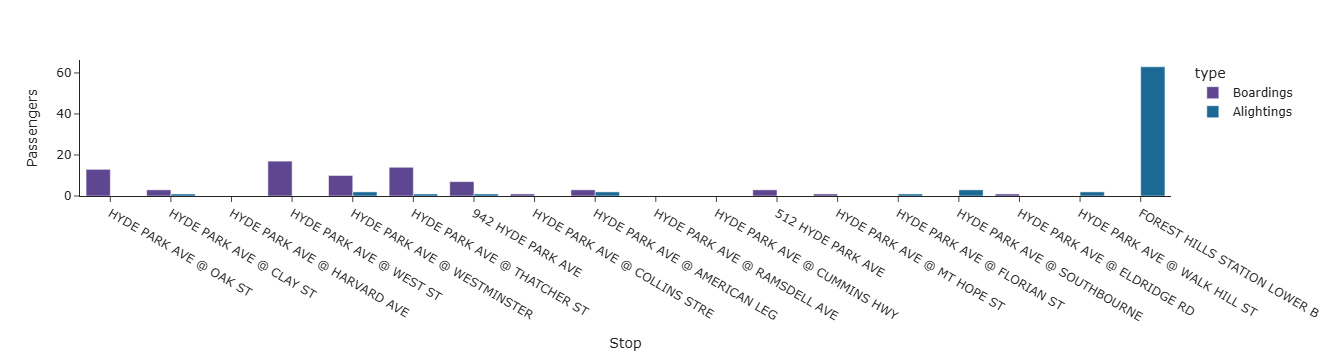

In [19]:
px.bar(
    pivot,
    x="stop_name",
    y="passengers",
    color="type",
    barmode="group",
    category_orders={"stop_name": pivot["stop_name"].unique()},
    template="simple_white",
    color_discrete_sequence=px.colors.qualitative.Prism,
    labels={
        "stop_name": "Stop",
        "passengers": "Passengers",
    },
)

# ridership map

In [20]:
stops_df = pivot.groupby("stop_name").agg(total_passengers=pd.NamedAgg("passengers", "sum")).reset_index()
stops_df

,stop_name,total_passengers
0,512 HYDE PARK AVE,3
1,942 HYDE PARK AVE,8
2,FOREST HILLS STATION LOWER B,63
3,HYDE PARK AVE @ AMERICAN LEG,5
4,HYDE PARK AVE @ CLAY ST,4
5,HYDE PARK AVE @ COLLINS STRE,1
6,HYDE PARK AVE @ CUMMINS HWY,0
7,HYDE PARK AVE @ ELDRIDGE RD,1
8,HYDE PARK AVE @ FLORIAN ST,1
9,HYDE PARK AVE @ HARVARD AVE,0


In [21]:
stops_df = stops_df.merge(stops_table, how='left', on='stop_name').drop_duplicates('stop_name')
stops_df

,stop_name,total_passengers,stop_id,lat,lon
0,512 HYDE PARK AVE,3,6479,42.282916,-71.118856
1,942 HYDE PARK AVE,8,6472,42.267483,-71.120878
2,FOREST HILLS STATION LOWER B,63,875,42.300621,-71.113471
3,HYDE PARK AVE @ AMERICAN LEG,5,6474,42.272938,-71.120024
4,HYDE PARK AVE @ CLAY ST,4,6466,42.257960,-71.123550
5,HYDE PARK AVE @ COLLINS STRE,1,6473,42.270586,-71.120440
6,HYDE PARK AVE @ CUMMINS HWY,0,6478,42.280244,-71.118828
8,HYDE PARK AVE @ ELDRIDGE RD,1,56479,42.292292,-71.117702
9,HYDE PARK AVE @ FLORIAN ST,1,16479,42.286702,-71.118576
10,HYDE PARK AVE @ HARVARD AVE,0,6467,42.259966,-71.122985


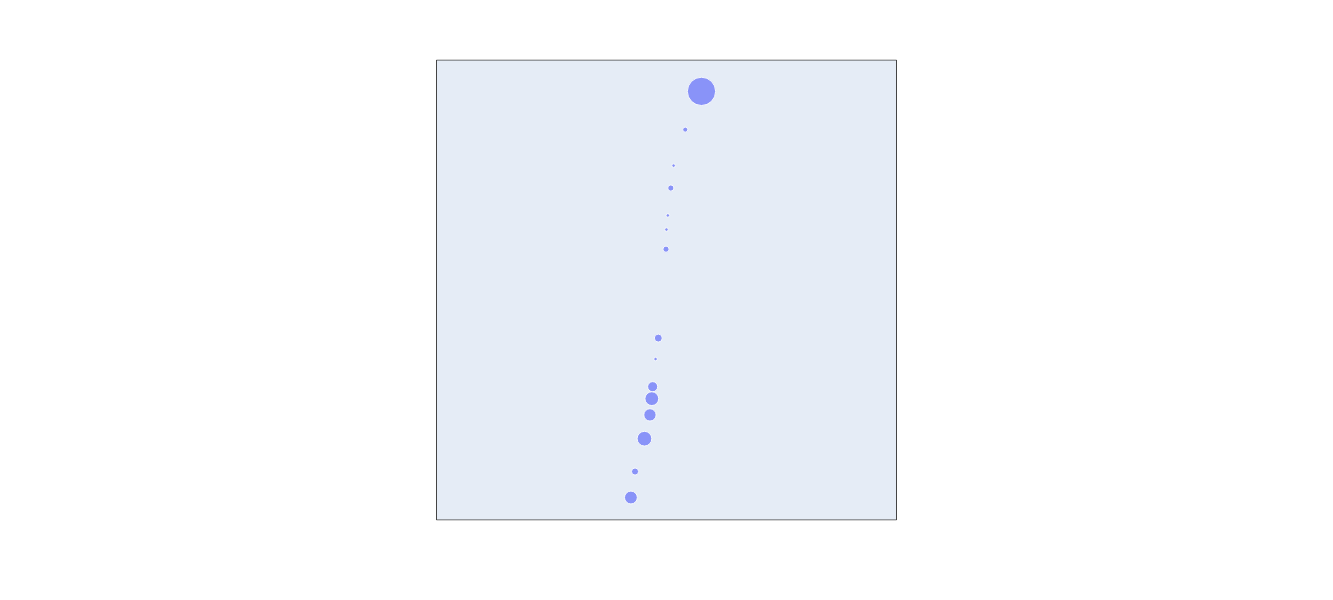

In [22]:
px.scatter_geo(
    stops_df,
    lat='lat',
    lon='lon',
    hover_data=['stop_name', 'total_passengers'],
    size="total_passengers",
    projection="mercator",
    fitbounds='locations',
    height=600
)

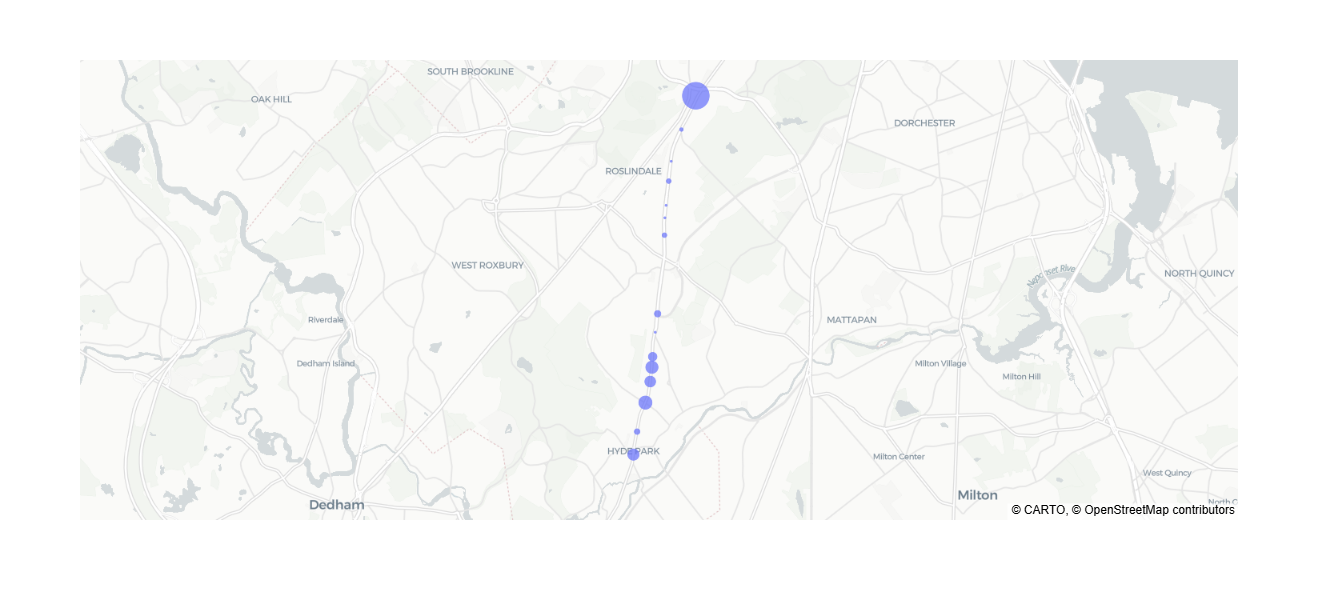

In [32]:
px.scatter_map(
    stops_df,
    lat='lat',
    lon='lon',
    hover_data=['stop_name', 'total_passengers'],
    size="total_passengers",
    height=600,
    map_style='carto-positron',
    zoom=12,
)